In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

In [5]:
"""QUESTION 1C"""
N = 1000
X = np.random.uniform(-2, 2, N)
epsilon = np.random.normal(0, np.sqrt(2), N)
Y = 1 + (2*X) + epsilon

X = X.reshape(-1, 1)

lin_reg = LinearRegression()
lin_reg.fit(X, Y)

y_pred_lin_reg = lin_reg.predict(X)

print("For Linear Regression: ",
      "\nSlope: ", lin_reg.coef_[0],
      "\nMSE: ", mean_squared_error(Y, y_pred_lin_reg),
      "\nR-2 Score: ", r2_score(Y, y_pred_lin_reg))
print()

lambdas = [1, 10, 100, 1000, 10000]

for lamb in lambdas:
    ridge = Ridge(alpha=lamb, random_state=42)
    ridge.fit(X, Y)
    y_pred_ridge = ridge.predict(X)
    print(f"Ridge Regression (Lambda = {lamb}):",
          f"Slope = {ridge.coef_[0]:3f}, MSE = {mean_squared_error(Y, y_pred_ridge):3f}, R2 = {r2_score(Y, y_pred_ridge):3f}")

For Linear Regression:  
Slope:  1.9736226355176945 
MSE:  2.160599413937531 
R-2 Score:  0.7025997017515229

Ridge Regression (Lambda = 1): Slope = 1.972118, MSE = 2.160602, R2 = 0.702599
Ridge Regression (Lambda = 10): Slope = 1.958676, MSE = 2.160892, R2 = 0.702559
Ridge Regression (Lambda = 100): Slope = 1.833692, MSE = 2.186258, R2 = 0.699068
Ridge Regression (Lambda = 1000): Slope = 1.119398, MSE = 3.116817, R2 = 0.570979
Ridge Regression (Lambda = 10000): Slope = 0.228664, MSE = 6.150691, R2 = 0.153375


In [18]:
"""QUESTION 2A"""
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)

df = pd.read_csv("flights.csv")
X = df.drop("ARRIVAL_DELAY", axis=1)
y = df["ARRIVAL_DELAY"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
con_mat = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

print("Confusion Matrix: \n")
print(con_mat)
print("--"*30)

TN, FP, FN, TP = cm.ravel()
print("True Positives: ", TP)
print("False Positives: ", FP)
print("True Negatives: ", TN)
print("False Negatives: ", FN)

print("--"*30)
print("Other Metrics: ")
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Error: {error:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1: {f1:.3f}")

Confusion Matrix: 

                 Predicted Negative  Predicted Positive
Actual Negative                 707                 544
Actual Positive                 505                 744
------------------------------------------------------------
True Positives:  744
False Positives:  544
True Negatives:  707
False Negatives:  505
------------------------------------------------------------
Other Metrics: 
Accuracy: 0.580
Error: 0.420
Precision: 0.578
Recall: 0.596
F1: 0.587


In [19]:
"""QUESTION 2B"""
coeffiencients = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coeffiencients
})
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)
print(coef_df)

                     Feature  Coefficient
3        SCHEDULED_DEPARTURE     0.437035
654  DESTINATION_AIRPORT_WRG     0.197158
95        ORIGIN_AIRPORT_CWA     0.152991
497  DESTINATION_AIRPORT_ISP     0.152417
16                AIRLINE_WN     0.141560
..                       ...          ...
658  DESTINATION_AIRPORT_YUM    -0.146941
218       ORIGIN_AIRPORT_MHT    -0.155931
524  DESTINATION_AIRPORT_LRD    -0.158592
133       ORIGIN_AIRPORT_FSM    -0.171173
338  DESTINATION_AIRPORT_ABI    -0.225254

[659 rows x 2 columns]


In [23]:
"""QUESTION 2C"""
y_prob = model.predict_proba(X_test)[:, 1]
thresholds = [0.25, 0.5, 0.75, 0.9]
results = []

for T in thresholds:
    y_pred_T = (y_prob >= T).astype(int)

    accuracy = accuracy_score(y_test, y_pred_T)
    precision = precision_score(y_test, y_pred_T, zero_division=0)
    recall = recall_score(y_test, y_pred_T, zero_division=0)

    results.append([T, accuracy, precision, recall])
results_df = pd.DataFrame(results, columns=["Threshold", "Accuracy", "Precision", "Recall"])
print("Performance: ")
print(results_df)

Performance: 
   Threshold  Accuracy  Precision    Recall
0       0.25    0.5280   0.514890  0.955164
1       0.50    0.5804   0.577640  0.595677
2       0.75    0.5152   0.596859  0.091273
3       0.90    0.5052   0.650000  0.020817


In [24]:
"""QUESTION 3"""
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logistic_gradient_descent(X, y, alpha=0.01, num_iters=100):
    n, d = X.shape
    theta = np.zeros(d)
    losses = []

    for i in range(num_iters):
        z = X @ theta
        h = sigmoid(z)

        epsilon = 1e-15
        loss = -np.mean(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
        grad = (1/n) * (X.T @ (h - y))
        theta -= (alpha * grad)
        losses.append(loss)

    return theta, losses

In [25]:
X_train_gd = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_gd = np.c_[np.ones(X_test.shape[0]), X_test]

y_train_gd = y_train.values
y_test_gd = y_test.values

learning_rates = [0.1, 0.01, 0.001]
iterations = [10, 50, 100]
loss_results = []

for alpha in learning_rates:
    for iters in iterations:
        theta, losses = logistic_gradient_descent(
            X_train_gd, y_train_gd, alpha=alpha, num_iters=iters
        )
        loss_results.append([alpha, iters, losses[-1]])

loss_df = pd.DataFrame(loss_results, columns=["alpha", "iterations", "loss"])
print("Cross-Entropy Loss Results: ")
print(loss_df)

Cross-Entropy Loss Results: 
   alpha  iterations      loss
0  0.100          10  0.666572
1  0.100          50  0.630035
2  0.100         100  0.622014
3  0.010          10  0.689783
4  0.010          50  0.677001
5  0.010         100  0.664934
6  0.001          10  0.692802
7  0.001          50  0.691294
8  0.001         100  0.689463


In [27]:
metric_results = []

for alpha in learning_rates:
    theta, _ = logistic_gradient_descent(
        X_train_gd, y_train_gd, alpha=alpha, num_iters=100
    )

    train_probs = sigmoid(X_train_gd @ theta)
    test_probs = sigmoid(X_test_gd @ theta)

    train_pred = (train_probs >= 0.5).astype(int)
    test_pred = (test_probs >= 0.5).astype(int)

    metric_results.append([
        alpha,
        accuracy_score(y_train_gd, train_pred),
        precision_score(y_train_gd, train_pred, zero_division=0),
        recall_score(y_train_gd, train_pred, zero_division=0),
        f1_score(y_train_gd, train_pred, zero_division=0),

        accuracy_score(y_test_gd, test_pred),
        precision_score(y_test_gd, test_pred, zero_division=0),
        recall_score(y_test_gd, test_pred, zero_division=0),
        f1_score(y_test_gd, test_pred, zero_division=0)
    ])

metrics_df = pd.DataFrame(
    metric_results,
    columns=[
        "Learning Rate",
        "Train Accuracy",
        "Train Precision",
        "Train Recall",
        "Train F1",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ]
)

print("\nMetrics at 100 Iterations:")
print(metrics_df)


Metrics at 100 Iterations:
   Learning Rate  Train Accuracy  Train Precision  Train Recall  Train F1  \
0          0.100        0.643067         0.639914      0.642493  0.641201   
1          0.010        0.635333         0.630343      0.641687  0.635964   
2          0.001        0.632000         0.627011      0.638464  0.632686   

   Test Accuracy  Test Precision  Test Recall   Test F1  
0         0.5776        0.575332     0.590072  0.582609  
1         0.5712        0.567300     0.597278  0.581903  
2         0.5712        0.567198     0.598078  0.582229  


In [32]:
"""QUESTION 4A"""
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

k_values = [3, 5, 7, 21]
results = []

for k in k_values:
    acc_list = []
    prec_list = []
    rec_list = []
    f1_list = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train.values[train_idx], y_train.values[val_idx]

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_tr, y_tr)

        y_val_pred = model.predict(X_val)

        acc_list.append(accuracy_score(y_val, y_val_pred))
        prec_list.append(precision_score(y_val, y_val_pred, zero_division=0))
        rec_list.append(recall_score(y_val, y_val_pred, zero_division=0))
        f1_list.append(f1_score(y_val, y_val_pred, zero_division=0))

    avg_acc = np.mean(acc_list)
    avg_err = 1 - avg_acc
    avg_prec = np.mean(prec_list)
    avg_rec = np.mean(rec_list)
    avg_f1 = np.mean(f1_list)

    results.append([k, avg_acc, avg_err, avg_prec, avg_rec, avg_f1])

results_df = pd.DataFrame(
    results, columns=["K", "Accuracy", "Error", "Precision", "Recall", "F1"]
)
print("5-Fold Cross-Validation Results for kNN: ")
print(results_df)

best_k = results_df.loc[results_df["Error"].idxmin(), "K"]
print(f"\nBest k (minimum CV error): {best_k}")

5-Fold Cross-Validation Results for kNN: 
    K  Accuracy     Error  Precision    Recall        F1
0   3  0.514133  0.485867   0.510563  0.524687  0.517321
1   5  0.524533  0.475467   0.520572  0.537884  0.528925
2   7  0.524000  0.476000   0.520056  0.539790  0.529360
3  21  0.533333  0.466667   0.528660  0.556947  0.542237

Best k (minimum CV error): 21


In [37]:
"""QUESTION 4B"""
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

results = []

knn = KNeighborsClassifier(n_neighbors=int(best_k))
knn.fit(X_train, y_train)

models = {
    "kNN": knn,
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
}

models["Logistic Regression"].fit(X_train, y_train)
models["LDA"].fit(X_train, y_train)

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append([
        name,
        "Train",
        accuracy_score(y_train, y_train_pred),
        1 - accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, zero_division=0),
        recall_score(y_train, y_train_pred, zero_division=0),
        f1_score(y_train, y_train_pred, zero_division=0),
    ])

    results.append([
        name,
        "Test",
        accuracy_score(y_test, y_test_pred),
        1 - accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
    ])

results_df = pd.DataFrame(results, columns=["Model", "Dataset", "Accuracy", "Error", "Precision", "Recall", "F1"])
print(results_df)

                 Model Dataset  Accuracy     Error  Precision    Recall  \
0                  kNN   Train  0.610000  0.390000   0.602835  0.628257   
1                  kNN    Test  0.519200  0.480800   0.518035  0.540432   
2  Logistic Regression   Train  0.648000  0.352000   0.644131  0.650013   
3  Logistic Regression    Test  0.580400  0.419600   0.577640  0.595677   
4                  LDA   Train  0.649467  0.350533   0.645401  0.652162   
5                  LDA    Test  0.579200  0.420800   0.575828  0.598879   

         F1  
0  0.615283  
1  0.528997  
2  0.647059  
3  0.586520  
4  0.648764  
5  0.587127  


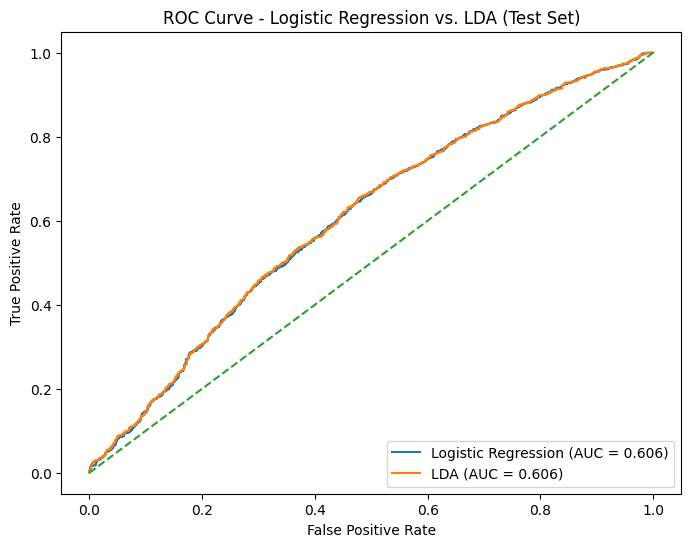

Logistic Regression AUC:  0.6058973477743026
LDA AUC:  0.607202948609887


In [38]:
"""QUESTION 4C"""
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_log = models["Logistic Regression"].predict_proba(X_test)[:, 1]
y_prob_lda = models["LDA"].predict_proba(X_test)[:, 1]

# Logistic REgression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

# LDA
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_prob_lda)
auc_lda = auc(fpr_lda, tpr_lda)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_lda, tpr_lda, label=f"LDA (AUC = {auc_log:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression vs. LDA (Test Set)")
plt.legend(loc="lower right")
plt.show()

print("Logistic Regression AUC: ", auc_log)
print("LDA AUC: ", auc_lda)

Threshold: 0.0 | FPR: 1.000 | TPR: 1.000
Threshold: 0.1 | FPR: 0.973 | TPR: 0.987
Threshold: 0.2 | FPR: 0.944 | TPR: 0.970
Threshold: 0.3 | FPR: 0.837 | TPR: 0.918
Threshold: 0.4 | FPR: 0.643 | TPR: 0.786
Threshold: 0.5 | FPR: 0.435 | TPR: 0.596
Threshold: 0.6 | FPR: 0.247 | TPR: 0.374
Threshold: 0.7 | FPR: 0.108 | TPR: 0.163
Threshold: 0.8 | FPR: 0.029 | TPR: 0.049
Threshold: 0.9 | FPR: 0.011 | TPR: 0.021
Threshold: 1.0 | FPR: 0.000 | TPR: 0.000


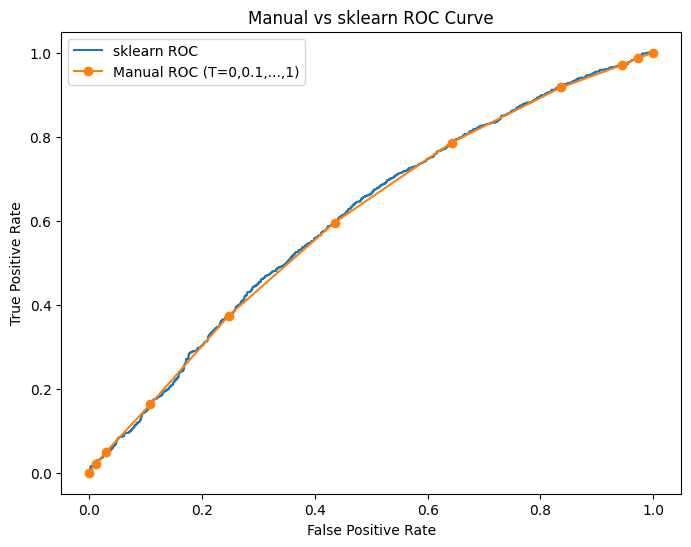

In [40]:
"""QUESTION 4D"""
y_prob_log = models["Logistic Regression"].predict_proba(X_test)[:, 1]
thresholds = np.arange(0, 1.1, 0.1)
tpr_list = []
fpr_list = []

for T in thresholds:
    y_pred_T = (y_prob_log >= T).astype(int)
    TP = np.sum((y_test == 1) & (y_pred_T == 1))
    FP = np.sum((y_test == 0) & (y_pred_T == 1))
    TN = np.sum((y_test == 0) & (y_pred_T == 0))
    FN = np.sum((y_test == 1) & (y_pred_T == 0))

    TPR = TP / (TP + FN) if (TP + FN) != 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) != 0 else 0

    tpr_list.append(TPR)
    fpr_list.append(FPR)

for T, fpr, tpr in zip(thresholds, fpr_list, tpr_list):
    print(f"Threshold: {T:.1f} | FPR: {fpr:.3f} | TPR: {tpr:.3f}")

fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(8,6))
plt.plot(fpr_sklearn, tpr_sklearn, label="sklearn ROC")
plt.plot(fpr_list, tpr_list, 'o-', label="Manual ROC (T=0,0.1,...,1)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual vs sklearn ROC Curve")
plt.legend()
plt.show()

In [60]:
"""QUESTION 5A"""
def k_fold_cv(model, X, y, k=5):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    np.random.seed(42)
    np.random.shuffle(indices)

    fold_sizes = np.full(k, n_samples // k)
    fold_sizes[:n_samples % k] += 1

    current = 0
    errors = []

    for fold_num, fold_size in enumerate(fold_sizes, start=1):
        start, stop = current, current + fold_size
        val_idx = indices[start:stop]
        train_idx = np.concatenate((indices[:start], indices[stop:]))

        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        fold_error = 1 - accuracy_score(y_val_fold, y_val_pred)
        errors.append(fold_error)

        # print(f"Fold {fold_num}: Validation Error = {fold_error:.4f}")
        current = stop

    avg_error = np.mean(errors)
    # print(f"\nAverage Validation Error across {k} folds: {avg_error:.4f}\n")
    return avg_error, list(map(lambda x: round(x, 3), errors))

In [62]:
"""QUESTION 5B"""
X_train_np = X_train.values if hasattr(X_train, "values") else X_train
y_train_np = y_train.values if hasattr(y_train, "values") else y_train

log_model = LogisticRegression(max_iter=1000, random_state=42)
avg_err_log, errors_log = k_fold_cv(log_model, X_train_np, y_train_np, k=5)
print(f"Per-fold errors: {errors_log}\n")
print(f"Avg Logistic Regression 5-fold CV error: {avg_err_log:.4f}\n")

lda_model = LinearDiscriminantAnalysis()
avg_err_lda, errors_lda = k_fold_cv(lda_model, X_train_np, y_train_np, k=5)
print(f"Per-fold errors: {errors_lda}\n")
print(f"Avg LDA 5-fold CV error: {avg_err_lda:.4f}\n")

print("-"*30)

avg_err_log, errors_log = k_fold_cv(log_model, X_train_np, y_train_np, k=10)
print(f"Per-fold errors: {errors_log}\n")
print(f"Avg Logistic Regression 10-fold CV error: {avg_err_log:.4f}\n")

avg_err_lda, errors_lda = k_fold_cv(lda_model, X_train_np, y_train_np, k=10)
print(f"Per-fold errors: {errors_lda}\n")
print(f"Avg LDA 10-fold CV error: {avg_err_lda:.4f}")

Per-fold errors: [0.403, 0.419, 0.425, 0.403, 0.409]

Avg Logistic Regression 5-fold CV error: 0.4119

Per-fold errors: [0.405, 0.419, 0.425, 0.406, 0.408]

Avg LDA 5-fold CV error: 0.4124

------------------------------
Per-fold errors: [0.407, 0.401, 0.421, 0.415, 0.423, 0.432, 0.383, 0.423, 0.397, 0.412]

Avg Logistic Regression 10-fold CV error: 0.4113

Per-fold errors: [0.408, 0.401, 0.424, 0.413, 0.421, 0.431, 0.381, 0.421, 0.388, 0.409]

Avg LDA 10-fold CV error: 0.4099
